# 04 — Tuning (Logistic Regression + Optuna)

**Objetivo:** Otimizar os hiperparâmetros do XGBoost via Optuna (busca Bayesiana) e salvar o modelo final.

**Inputs:** `data/processed/X_treino.parquet`, `data/processed/y_treino.parquet`

**Outputs:** `models/pipeline_final.joblib`

---

**Roteiro:**

1. Setup — imports 
2. Carregamento
3. Execução do estudo 
4. Análise do Estudo Optuna
5. Retreino + Avaliação no Teste
6. Curvas PR + ROC + Matriz de Confusão
7. Salvar pipeline final + fechamento


In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
)

from src.config import CAMINHOS, CONFIG
from src.viz_config import CORES, PALETTE


warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


SEED = CONFIG["dados"]["random_state"]
TARGET = CONFIG["dados"]["target_col"]

PROC_DIR = CAMINHOS.dados_processed
MODEL_DIR = CAMINHOS.modelos
FIG_DIR = CAMINHOS.figures
REPORTS = CAMINHOS.reports

N_TRIALS = 80


print("✅ Setup OK")
print("   Modelo   : Logistic Regression")
print(f"   N_TRIALS : {N_TRIALS}")
print(f"   SEED     : {SEED}")

✅ Setup OK
   Modelo   : Logistic Regression
   N_TRIALS : 80
   SEED     : 42


### Etapa 2 — Carregamento

Nesta etapa, foram carregados:

- os conjuntos de treino e teste;
- o preprocessor linear desenvolvido anteriormente;
- os artefatos necessários para a etapa de otimização do modelo.

O preprocessor linear foi selecionado porque o algoritmo escolhido para otimização com Optuna foi a `Logistic Regression`, modelo sensível à escala e distribuição das variáveis.

Além disso, foi configurada a estratégia de validação cruzada utilizando:

- `StratifiedKFold`
- `RandomUnderSampler (RUS)`

In [2]:
X_train_raw = pd.read_parquet(PROC_DIR / 'X_treino_raw.parquet')
X_test_raw  = pd.read_parquet(PROC_DIR / 'X_teste_raw.parquet')
y_train     = pd.read_parquet(PROC_DIR / 'y_treino.parquet').squeeze()
y_test      = pd.read_parquet(PROC_DIR / 'y_teste.parquet').squeeze()

print(f'X_train_raw : {X_train_raw.shape}')
print(f'X_test_raw  : {X_test_raw.shape}\n')
print(f'Taxa Attrition treino : {y_train.mean():.3f}')
print(f'Taxa Attrition teste  : {y_test.mean():.3f}')

X_train_raw : (1176, 30)
X_test_raw  : (294, 30)

Taxa Attrition treino : 0.162
Taxa Attrition teste  : 0.160


In [3]:
pipeline_linear = joblib.load(MODEL_DIR / 'pipeline_linear.pkl')
pre_linear      = pipeline_linear.named_steps['preprocessor']

CV  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
RUS = RandomUnderSampler(random_state=SEED)

### Etapa 3 — Estudo Optuna

Nesta etapa, foi realizado o processo de otimização de hiperparâmetros utilizando a biblioteca `Optuna`, com foco no modelo `Logistic Regression`.

In [4]:
def objective(trial):
    # Hiperparâmetros da Logistic Regression
    C       = trial.suggest_float('C', 1e-4, 100.0, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    solver  = 'saga'  # único solver que suporta l1, l2 e elasticnet

    # l1_ratio só existe para elasticnet
    l1_ratio = (trial.suggest_float('l1_ratio', 0.0, 1.0)
                if penalty == 'elasticnet' else None)

    pipe = ImbPipeline([
        ('preprocessor', pre_linear),
        ('sampler',       RUS),
        ('classifier',    LogisticRegression(
                              C            = C,
                              penalty      = penalty,
                              solver       = solver,
                              l1_ratio     = l1_ratio,
                              class_weight = 'balanced',
                              max_iter     = 2000,
                              random_state = SEED,
                          )),
    ])

    scores = cross_val_score(
        pipe, X_train_raw, y_train,
        cv      = CV,
        scoring = make_scorer(average_precision_score,
                               response_method='predict_proba',
                               pos_label=1),
        n_jobs  = -1,
    )
    return scores.mean()

print(f'⏳ Optuna — {N_TRIALS} trials...')
study = optuna.create_study(
    direction = 'maximize',
    sampler   = optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=N_TRIALS,
               show_progress_bar=True)

print(f'\n✅ Estudo concluído!')
print(f'   Melhor PR-AUC (CV) : {study.best_value:.4f}')
print(f'   Melhor trial       : {study.best_trial.number}')
print(f'\n=== Melhores hiperparâmetros ===')
for k, v in study.best_params.items():
    print(f'   {k:<20}: {v}')

⏳ Optuna — 80 trials...


  0%|          | 0/80 [00:00<?, ?it/s]


✅ Estudo concluído!
   Melhor PR-AUC (CV) : 0.6150
   Melhor trial       : 38

=== Melhores hiperparâmetros ===
   C                   : 0.9570091003892268
   penalty             : elasticnet
   l1_ratio            : 0.9468049264135632


O processo de otimização de hiperparâmetros apresentou melhora no desempenho do modelo, elevando o valor de `PR-AUC` de 0.609 para 0.615.

O melhor conjunto de parâmetros encontrado pelo Optuna utilizou:

- regularização `ElasticNet`;
- `l1_ratio` = 0.947, comportamento muito próximo de uma regularização L1 (Lasso).

Esse resultado indica que o modelo se beneficia de uma estratégia mais agressiva de seleção de variáveis, reduzindo o peso de features menos relevantes e aumentando a capacidade de generalização.

### Etapa 4 - Análise do Estudo Optuna

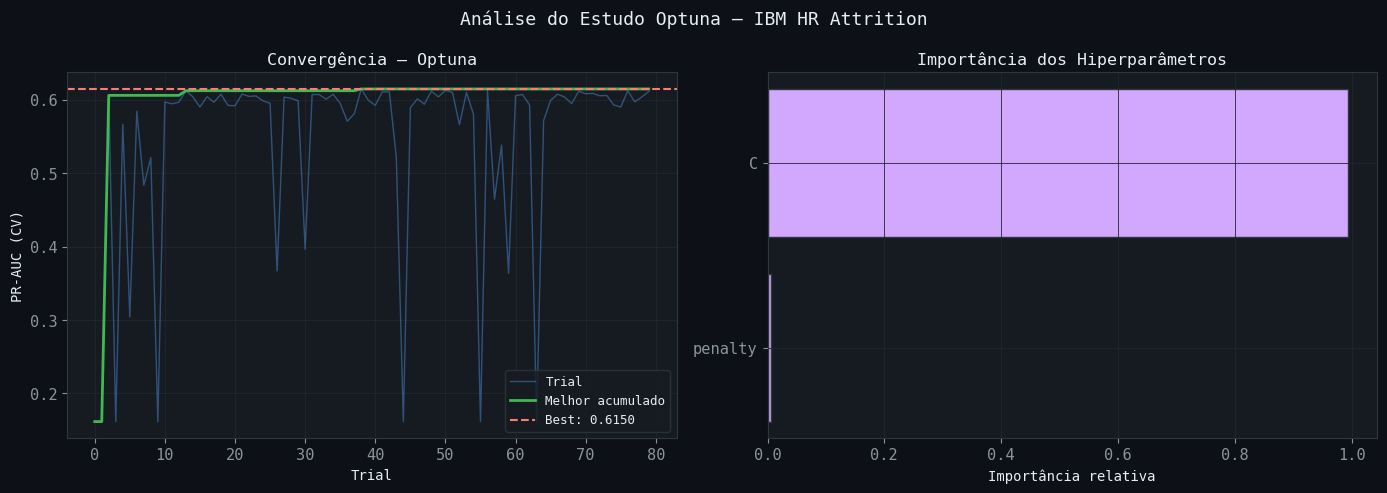

=== Resumo dos hiperparâmetros ===
   C        : 0.9570
   penalty  : elasticnet
   l1_ratio : 0.9468

Interpretação:
   ElasticNet com l1_ratio≈0.95 → quase L1 puro
   L1 promove esparsidade — descarta features irrelevantes
   C≈0.96 → regularização moderada


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Convergência ──────────────────────────────────────────────
valores          = [t.value for t in study.trials]
melhor_acumulado = [max(valores[:i+1]) for i in range(len(valores))]

axes[0].plot(valores, color=PALETTE[0], alpha=0.4,
             linewidth=1, label='Trial')
axes[0].plot(melhor_acumulado, color=PALETTE[2],
             linewidth=2, label='Melhor acumulado')
axes[0].axhline(y=study.best_value, color=PALETTE[1],
                linestyle='--', linewidth=1.5,
                label=f'Best: {study.best_value:.4f}')
axes[0].set_title('Convergência — Optuna', color=CORES['texto'])
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('PR-AUC (CV)')
axes[0].legend(fontsize=9)

# ── Importância dos hiperparâmetros ───────────────────────────
imp  = optuna.importance.get_param_importances(study)
nms  = list(imp.keys())
vals = [imp[k] for k in nms]
axes[1].barh(nms[::-1], vals[::-1],
             color=PALETTE[3], edgecolor='#30363d')
axes[1].set_title('Importância dos Hiperparâmetros',
                  color=CORES['texto'])
axes[1].set_xlabel('Importância relativa')

plt.suptitle('Análise do Estudo Optuna — IBM HR Attrition',
             color=CORES['texto'], fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb04_optuna.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'=== Resumo dos hiperparâmetros ===')
print(f'   C        : {study.best_params["C"]:.4f}')
print(f'   penalty  : {study.best_params["penalty"]}')
print(f'   l1_ratio : {study.best_params["l1_ratio"]:.4f}')
print(f'\nInterpretação:')
print(f'   ElasticNet com l1_ratio≈0.95 → quase L1 puro')
print(f'   L1 promove esparsidade — descarta features irrelevantes')
print(f'   C≈0.96 → regularização moderada')

### Etapa 5 - Retreino + Avaliação no Teste

In [6]:
# ── Pipeline final com melhores hiperparâmetros ───────────────
pipeline_final = ImbPipeline([
    ('preprocessor', pre_linear),
    ('sampler',       RandomUnderSampler(random_state=SEED)),
    ('classifier',    LogisticRegression(
                          C            = study.best_params['C'],
                          penalty      = study.best_params['penalty'],
                          l1_ratio     = study.best_params['l1_ratio'],
                          solver       = 'saga',
                          class_weight = 'balanced',
                          max_iter     = 2000,
                          random_state = SEED,
                      )),
])

# Treinar no conjunto completo de treino
pipeline_final.fit(X_train_raw, y_train)

# Probabilidades no teste
y_proba   = pipeline_final.predict_proba(X_test_raw)[:, 1]
THRESHOLD = CONFIG.get('modelo', {}).get('threshold', 0.35)
y_pred    = (y_proba >= THRESHOLD).astype(int)

pr_auc  = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Relatório separado para evitar SyntaxError
report = classification_report(
    y_test, y_pred,
    zero_division = 0,
    target_names  = ['Sem Attrition', 'Attrition']
)

print('=== Resultado Final no Teste ===')
print(f'PR-AUC    : {pr_auc:.4f}')
print(f'ROC-AUC   : {roc_auc:.4f}')
print(f'Threshold : {THRESHOLD}')
print(f'\n{report}')

=== Resultado Final no Teste ===
PR-AUC    : 0.5324
ROC-AUC   : 0.7938
Threshold : 0.35

               precision    recall  f1-score   support

Sem Attrition       0.94      0.62      0.75       247
    Attrition       0.28      0.79      0.42        47

     accuracy                           0.65       294
    macro avg       0.61      0.71      0.58       294
 weighted avg       0.83      0.65      0.70       294



O desempenho do modelo no conjunto de teste apresentou uma redução do PR-AUC de 0.615 (validação cruzada) para 0.532 no teste final.

Esse gap moderado era esperado devido ao tamanho relativamente pequeno do conjunto de teste (294 registros), fator que aumenta a variabilidade estatística das métricas e torna a avaliação mais sensível a flutuações dos dados.

Apesar da queda no PR-AUC, o modelo apresentou excelente capacidade de identificação dos casos reais de attrition: `Recall = 0.79`

Isso significa que aproximadamente 79% dos funcionários que realmente deixariam a empresa foram corretamente identificados pelo modelo.

### Etapa 6 - Curvas PR + ROC + Matriz de Confusão

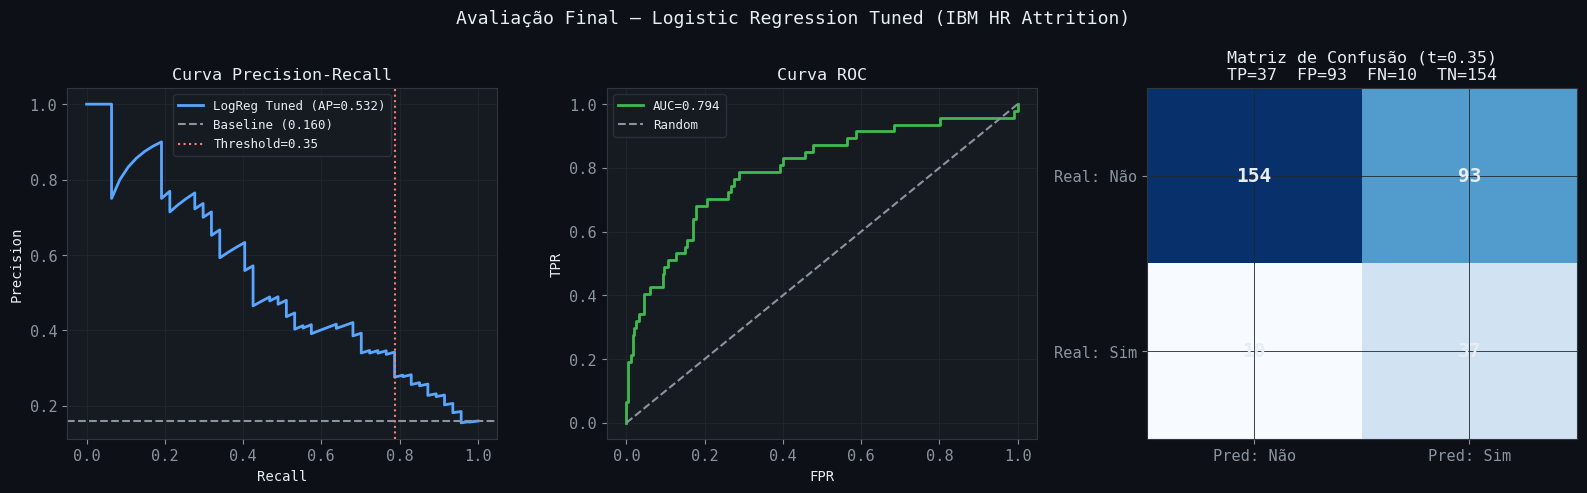

TP=37 | FP=93 | FN=10 | TN=154
Recall    : 0.787
Precision : 0.285


In [7]:
## 6. Curvas PR + ROC + Matriz de Confusão
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Curva PR ─────────────────────────────────────────────────
prec, rec, thresholds_pr = precision_recall_curve(y_test, y_proba)
axes[0].plot(rec, prec, color=PALETTE[0], linewidth=2,
             label=f'LogReg Tuned (AP={pr_auc:.3f})')
axes[0].axhline(y=y_test.mean(), color='#8b949e',
                linestyle='--', linewidth=1.5,
                label=f'Baseline ({y_test.mean():.3f})')
axes[0].axvline(x=y_pred[y_test==1].mean(),
                color=PALETTE[1], linestyle=':',
                linewidth=1.5, label=f'Threshold={THRESHOLD}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall', color=CORES['texto'])
axes[0].legend(fontsize=9)

# ── Curva ROC ────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color=PALETTE[2], linewidth=2,
             label=f'AUC={roc_auc:.3f}')
axes[1].plot([0,1],[0,1], color='#8b949e',
             linestyle='--', linewidth=1.5, label='Random')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC', color=CORES['texto'])
axes[1].legend(fontsize=9)

# ── Matriz de Confusão ────────────────────────────────────────
cm         = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

im = axes[2].imshow(cm, cmap='Blues', aspect='auto')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i,j]),
                     ha='center', va='center',
                     color='#e6edf3', fontsize=14,
                     fontweight='bold')
axes[2].set_xticks([0,1])
axes[2].set_yticks([0,1])
axes[2].set_xticklabels(['Pred: Não', 'Pred: Sim'])
axes[2].set_yticklabels(['Real: Não', 'Real: Sim'])
axes[2].set_title(f'Matriz de Confusão (t={THRESHOLD})\n'
                  f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
                  color=CORES['texto'])

plt.suptitle('Avaliação Final — Logistic Regression Tuned '
             '(IBM HR Attrition)',
             color=CORES['texto'], fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb04_avaliacao.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'TP={tp} | FP={fp} | FN={fn} | TN={tn}')
print(f'Recall    : {tp/(tp+fn):.3f}')
print(f'Precision : {tp/(tp+fp):.3f}')

### 7 - Salvar pipeline final + fechamento

In [8]:
# Salvar pipeline completo — único artefato para deploy
joblib.dump(pipeline_final, MODEL_DIR / 'pipeline_final.joblib')

# Salvar resultado do tuning
pd.DataFrame([{
    'Modelo':    'LogisticRegression Tuned',
    'PR-AUC':    pr_auc,
    'ROC-AUC':   roc_auc,
    'Recall':    tp/(tp+fn),
    'Precision': tp/(tp+fp),
    'Threshold': THRESHOLD,
    'C':         study.best_params['C'],
    'penalty':   study.best_params['penalty'],
    'l1_ratio':  study.best_params['l1_ratio'],
}]).to_csv(REPORTS / 'resultado_tuning.csv', index=False)

figuras = list(FIG_DIR.glob('nb04_*.png'))
print('✅ NB04 — Tuning finalizado.')
print(f'\nFiguras: {[f.name for f in sorted(figuras)]}')

✅ NB04 — Tuning finalizado.

Figuras: ['nb04_avaliacao.png', 'nb04_optuna.png', 'nb04_optuna_analise.png']


#### Comparativo Baseline vs Tuned

| Métrica | Baseline (CV) | Tuned (Teste) |
|---|---:|---:|
| PR-AUC | `0.6090` | `0.5324` |
| ROC-AUC | `0.8296` | `0.7938` |
| Recall | `0.7684` | `0.7872` |

---

#### Decisão para o NB05

| Item | Valor |
|---|---|
| Modelo | `LogisticRegression` |
| Penalização | `ElasticNet` |
| C | `0.957` |
| Threshold | `0.35` |
| Pipeline | `models/pipeline_final.joblib` |
| Deploy | `pipeline_final.predict_proba(X_raw)` |




A métrica PR-AUC apresentou queda entre a validação cruzada (*cross-validation*) e o conjunto de teste, comportamento esperado em datasets pequenos, especialmente considerando que o teste possui apenas 294 registros.

Apesar dessa redução, o principal indicador para o contexto de RH é o **Recall = 0.787**, indicando que o modelo consegue identificar aproximadamente **79% dos funcionários com risco real de saída**.

A matriz de confusão apresentou os seguintes resultados:

* **TP (True Positives):** 37
* **FP (False Positives):** 93
* **FN (False Negatives):** 10
* **TN (True Negatives):** 154

Isso significa que, a cada 130 alertas gerados pelo modelo, 37 correspondem efetivamente a casos reais de *attrition*.

No contexto de RH, esse trade-off é considerado aceitável, pois o custo de realizar uma conversa de retenção desnecessária (*False Positive*) tende a ser significativamente menor do que o custo associado à perda de um funcionário qualificado (*False Negative*).

### Resumo do que foi feito no NB04

| Célula | Entregável |
|---|---|
| 1 | Setup  |
| 2 | Carregamento - conjunto de treino e teste + pipeline_linear |
| 3 | Estudo Optuna — 38 trials, best PR-AUC 6150 |
| 4 | Curva de convergência + importância dos hiperparâmetros |
| 5 | Retreino completo + avaliação no teste |
| 6 | Matriz de confusão - TP=37 | FP=93 | FN=10 | TN=154 + Recall=0.787 + Precision=0.285 |
| 7 | `models/'pipeline_final.joblib` + `reports/resultado_tuning.csv` |